# A Handbag-Shoes classifier using CNN and ImageNet 

## Initialization

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

keras.utils.set_random_seed(42)

2026-01-18 15:29:29.049992: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-18 15:29:29.093497: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-18 15:29:30.034904: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Getting the Data

In [2]:


def get_data():
    
    import os
    import subprocess
    from pathlib import Path

    DATA_DIR = Path("./handbags-shoes")
    ZIP_FILE = Path("./handbags-shoes.zip")
    URL = "https://www.dropbox.com/s/w07liww46kgxo1m/handbags-shoes.zip?dl=1"

    # Case 1: data already extracted
    if DATA_DIR.exists():
        print(f"✅ Data already present at: {DATA_DIR.resolve()}")
        return DATA_DIR

    # Case 2: zip exists but not extracted
    if ZIP_FILE.exists():
        print("📦 Zip file found. Extracting...")
        subprocess.run(
            ["unzip", "-qq", str(ZIP_FILE)],
            check=True
        )
        return DATA_DIR

    # Case 3: nothing exists → download
    print("⬇️ Downloading dataset...")
    subprocess.run(
        ["wget", "-O", str(ZIP_FILE), URL],
        check=True
    )

    print("📦 Extracting dataset...")
    subprocess.run(
        ["unzip", "-qq", str(ZIP_FILE)],
        check=True
    )

    return DATA_DIR
data_path = get_data()
print(data_path)


✅ Data already present at: /home/saurabh-singh/Documents/GitHub/MastersDS/MIT-15.773/handbags-shoes
handbags-shoes


## Data Pre-Processing

In [3]:
import os
import shutil
import pathlib

base_dir = pathlib.Path.cwd() / "handbags-shoes"

splits = {
    "train": slice(0, 50),
    "validation": slice(50, 75),
    "test": slice(75, None),
}

for category in ("handbags", "shoes"):
    fnames = os.listdir(base_dir / category)

    for split, sl in splits.items():
        out_dir = base_dir / split / category
        os.makedirs(out_dir, exist_ok=True)

        for fname in fnames[sl]:
            src = base_dir / category / fname
            dst = out_dir / fname

            # avoid re-copying if the file already exists
            if not dst.exists():
                shutil.copyfile(src, dst)


In [4]:
# Loading the data into Kears 

train_dataset = keras.utils.image_dataset_from_directory(
    base_dir / "train" , 
    image_size = (224, 224),
    batch_size = 32,
)

validation_dataset = keras.utils.image_dataset_from_directory(
    base_dir / "validation",
    image_size = (224, 224), 
    batch_size = 32,
)
validation_dataset = keras.utils.image_dataset_from_directory(
    base_dir / "validation",
    image_size = (224, 224), 
    batch_size = 32,
)
test_dataset = keras.utils.image_dataset_from_directory(
    base_dir / "test",
    image_size = (224, 224), 
    batch_size = 32,
)

Found 97 files belonging to 2 classes.


I0000 00:00:1768730371.034752   75026 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10247 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 50 files belonging to 2 classes.
Found 50 files belonging to 2 classes.
Found 38 files belonging to 2 classes.


In [5]:
for images, _ in train_dataset.take(1):
    print(images[0].shape)

(224, 224, 3)


2026-01-18 15:29:31.927086: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-01-18 15:29:32.066926: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


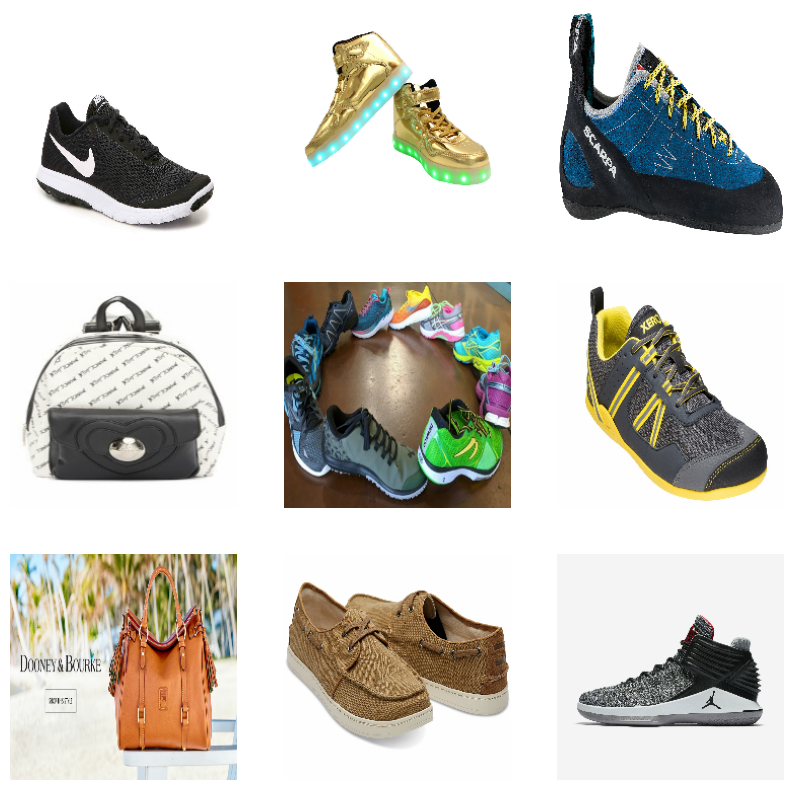

In [6]:
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1 )
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

## CNN Model 

In [7]:
input = keras.Input(shape=(224,224,3)) # in torch it should be (3,244,244)

h = keras.layers.Rescaling(1./255)(input)

h = keras.layers.Conv2D(
    32,
    kernel_size = (2,2),
    activation="relu",
    name="Conv_1"
)(h)

h = keras.layers.MaxPool2D()(h)

h = keras.layers.Conv2D(
    32,
    kernel_size = (2,2),
    activation="relu",
    name="Conv_2"
)(h)

h = keras.layers.MaxPool2D()(h)

h = keras.layers.Flatten()(h)

output = keras.layers.Dense(1, activation="sigmoid")(h)
model = keras.Model(input, output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 223, 223, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 110, 110, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        96,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,345 (395.88 KB)

 Trainable params: 101,345 (395.88 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Standard function to print loss 

def plot_loss_curves(history):
    plt.clf()
    history_dict = history.history
    loss_values = history_dict["loss"]
    validation_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)
    plt.plot(epochs, loss_values, "bo", label="Training Loss")
    plt.plot(epochs, validation_loss_values, "b", label="Validation Loss")
    plt.title("Training and validation loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.legend()
    plt.show()
    
def plot_acc_curves(history):
    plt.clf()
    history_dict = history.history
    acc = history_dict["accuracy"]
    validation_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training accuracy")
    plt.plot(epochs, validation_acc, "b", label="validation accuracy")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
    
    

## Training CNN Model 

In [9]:
model.compile(
    loss = "binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

Epoch 1/20


2026-01-18 15:29:33.164674: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f432c004a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-18 15:29:33.164714: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-18 15:29:33.187758: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-18 15:29:33.304362: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


1/4 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.4375 - loss: 0.7289

I0000 00:00:1768730375.157137   75169 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 549ms/step - accuracy: 0.4742 - loss: 1.6613 - val_accuracy: 0.5000 - val_loss: 2.0816
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4948 - loss: 2.1358 - val_accuracy: 0.5000 - val_loss: 0.8776
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6289 - loss: 0.6779 - val_accuracy: 0.5000 - val_loss: 0.8307
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5052 - loss: 0.7945 - val_accuracy: 0.5200 - val_loss: 0.6800
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7423 - loss: 0.5435 - val_accuracy: 0.5000 - val_loss: 0.7556
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5258 - loss: 0.6675 - val_accuracy: 0.7000 - val_loss: 0.5851
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9278 - loss: 0.4446 - val_accuracy: 0.6600 - val_loss: 0.5747
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7835 - loss: 0.4316 - val_accuracy: 0.6200 - val_loss: 0.5856
Epoch 9/20

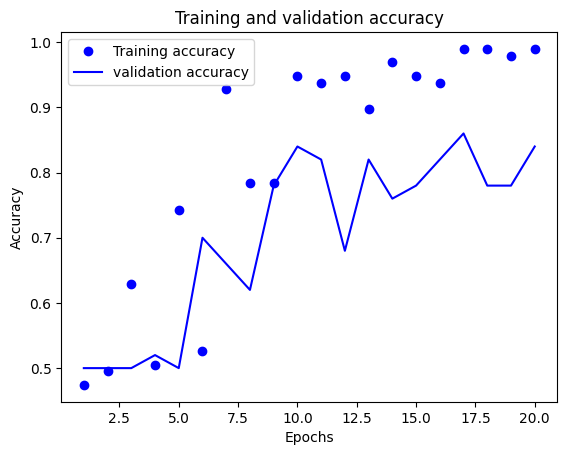

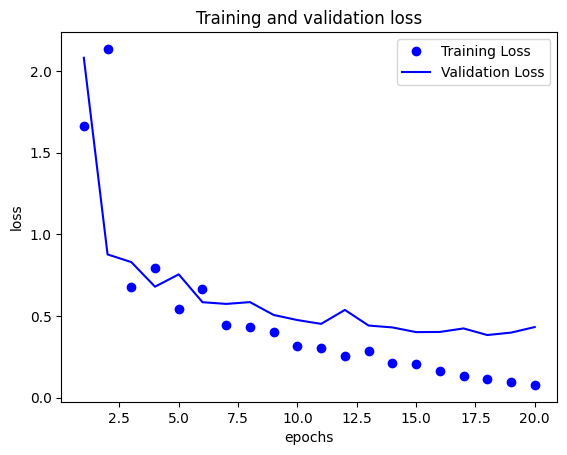

In [10]:
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data = validation_dataset
)

plot_acc_curves(history=history)
plot_loss_curves(history=history)



In [11]:
score = model.evaluate(test_dataset)
print("test accuracy : ", score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.8158 - loss: 0.5567
test accuracy :  0.8157894611358643


## Data Augmentation

In [12]:
def augment_data(image):
    x = keras.layers.RandomFlip("horizontal")(image)
    x = keras.layers.RandomRotation(0.1)(x)
    x = keras.layers.RandomZoom(0.2)(x)
    return x

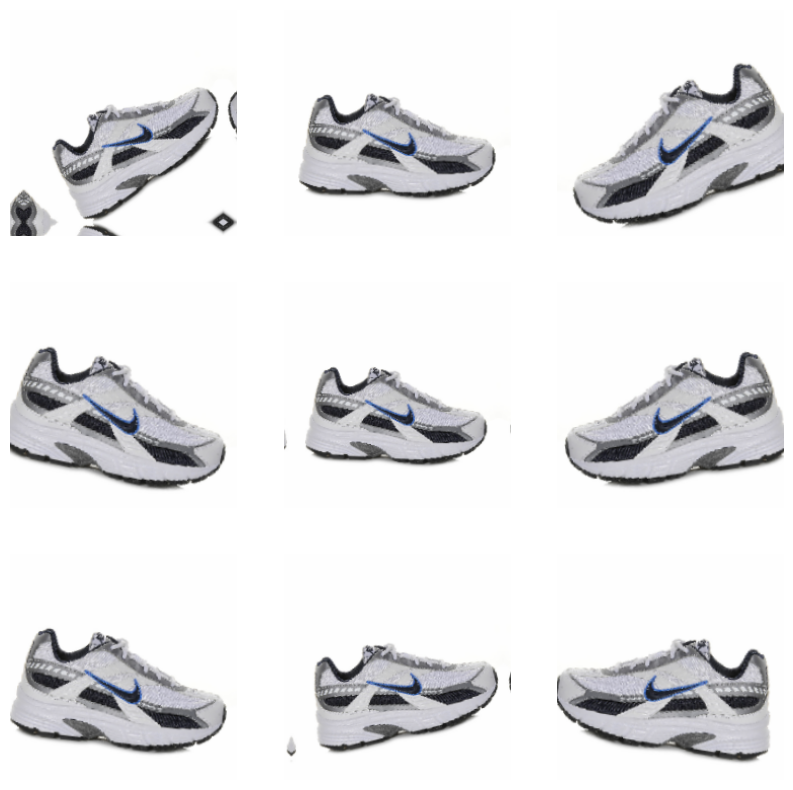

In [13]:
plt.figure(figsize=(10,10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = augment_data(images[0])
        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.axis("off")


## Model with augmented data

In [14]:
input = keras.Input(shape=(224,224,3)) # in torch it should be (3,244,244)

# ------ Augmented Layer in the previous model --------------------

h = keras.layers.RandomFlip("horizontal")(input)
h = keras.layers.RandomRotation(0.1)(h)
h = keras.layers.RandomZoom(0.2)(h)


# ================================================================

h = keras.layers.Rescaling(1./255)(h)

h = keras.layers.Conv2D(
    32,
    kernel_size = (2,2),
    activation="relu",
    name="Conv_1"
)(h)

h = keras.layers.MaxPool2D()(h)

h = keras.layers.Conv2D(
    32,
    kernel_size = (2,2),
    activation="relu",
    name="Conv_2"
)(h)

h = keras.layers.MaxPool2D()(h)

h = keras.layers.Flatten()(h)

output = keras.layers.Dense(1, activation="sigmoid")(h)
model = keras.Model(input, output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_9 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_9               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_9 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 223, 223, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 110, 110, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 96800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        96,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,345 (395.88 KB)

 Trainable params: 101,345 (395.88 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    loss = "binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

Epoch 1/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.5258 - loss: 1.1370 - val_accuracy: 0.5600 - val_loss: 0.8685
Epoch 2/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5876 - loss: 0.7118 - val_accuracy: 0.5400 - val_loss: 0.6071
Epoch 3/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6082 - loss: 0.6328 - val_accuracy: 0.7400 - val_loss: 0.5362
Epoch 4/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7732 - loss: 0.5844 - val_accuracy: 0.7800 - val_loss: 0.5080
Epoch 5/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7629 - loss: 0.5335 - val_accuracy: 0.7600 - val_loss: 0.4436
Epoch 6/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7113 - loss: 0.5096 - val_accuracy: 0.7600 - val_loss: 0.4874
Epoch 7/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6392 - loss: 0.6093 - val_accuracy: 0.8600 - val_loss: 0.4143
Epoch 8/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6804 - loss: 0.6005 - val_accuracy: 0.6600 - val_loss: 0.6548


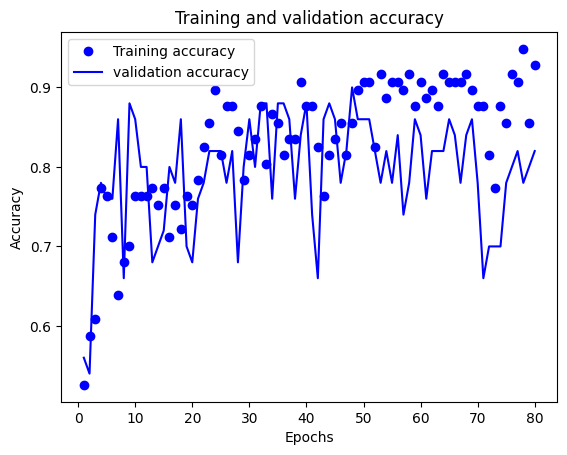

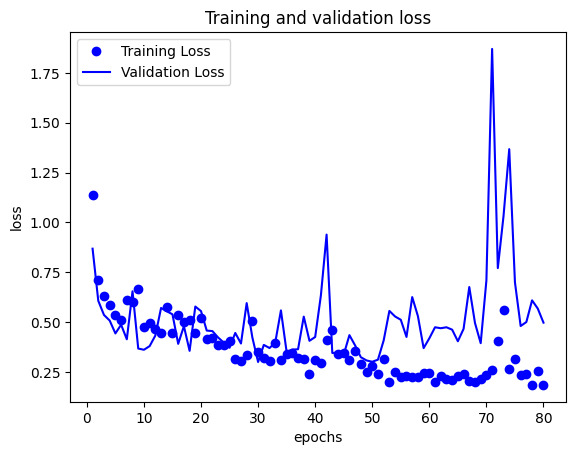

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8158 - loss: 0.4391
test accuracy :  0.8157894611358643


In [16]:

history = model.fit(
    train_dataset,
    epochs=80,
    validation_data = validation_dataset
)

plot_acc_curves(history=history)
plot_loss_curves(history=history)
score = model.evaluate(test_dataset)
print("test accuracy : ", score[1])

## Model 3 with changes from chatgpt

In [17]:
input = keras.Input(shape=(224,224,3)) # in torch it should be (3,244,244)

# ------ Augmented Layer in the previous model --------------------

h = keras.layers.RandomFlip("horizontal")(input)
h = keras.layers.RandomRotation(0.05)(h)
h = keras.layers.RandomZoom(0.1)(h)


# ================================================================

h = keras.layers.Rescaling(1./255)(h)

h = keras.layers.Conv2D(
    32,
    kernel_size = (3,3),
    activation="relu",
    name="Conv_1"
)(h)

h = keras.layers.MaxPool2D()(h)

h = keras.layers.Conv2D(
    32,
    kernel_size = (3,3),
    activation="relu",
    name="Conv_2"
)(h)

h = keras.layers.MaxPool2D()(h)

h = keras.layers.GlobalAveragePooling2D()(h)

output = keras.layers.Dense(1, activation="sigmoid")(h)
model = keras.Model(input, output)
model.summary()

model.compile(
    loss = "binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_10 (RandomFlip)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_10              │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_10 (RandomZoom)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,177 (39.75 KB)

 Trainable params: 10,177 (39.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.5155 - loss: 0.6951 - val_accuracy: 0.5000 - val_loss: 0.6962
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4948 - loss: 0.6963 - val_accuracy: 0.5000 - val_loss: 0.7104
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4948 - loss: 0.7086 - val_accuracy: 0.5000 - val_loss: 0.7249
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4948 - loss: 0.7181 - val_accuracy: 0.5000 - val_loss: 0.7249
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4948 - loss: 0.7037 - val_accuracy: 0.5400 - val_loss: 0.6919
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5670 - loss: 0.6844 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5052 - loss: 0.6976 - val_accuracy: 0.5000 - val_loss: 0.7161
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5052 - loss: 0.7246 - val_accuracy: 0.5000 - val_loss: 0.7349

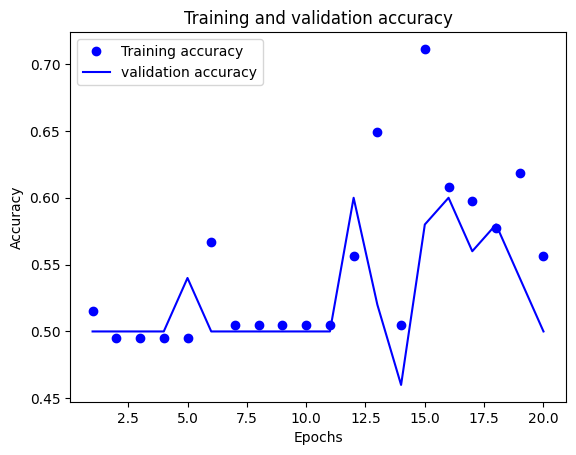

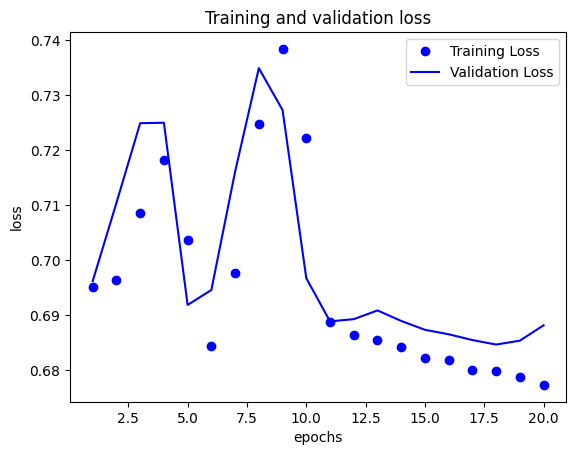

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4211 - loss: 0.7014
test accuracy :  0.42105263471603394


In [18]:

history = model.fit(
    train_dataset,
    epochs=20,
    validation_data = validation_dataset
)

plot_acc_curves(history=history)
plot_loss_curves(history=history)
score = model.evaluate(test_dataset)
print("test accuracy : ", score[1])

## Usin Resnet50 for transfer learining

In [19]:
resnet50_base = keras.applications.ResNet50(
    weights="imagenet",
    include_top = False,
    input_shape=(224,224,3)
)

resnet50_base.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [20]:
# getting features and labels from the resnet

def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.resnet50.preprocess_input(images)
        features = resnet50_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features , train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


2026-01-18 15:30:10.842437: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [21]:
train_features.shape

(97, 7, 7, 2048)

In [22]:
# transfer learning 

input = keras.layers.Input(shape=(7,7,2048))
h = keras.layers.Flatten()(input)
h = keras.layers.Dense(256, activation="relu")(h)
h = keras.layers.Dropout(0.5)(h)
output = keras.layers.Dense(1,activation="sigmoid")(h)
model = keras.Model(input,output)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 7, 7, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,690,625 (98.00 MB)

 Trainable params: 25,690,625 (98.00 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    loss = "binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 240ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 4.0785e-13 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 

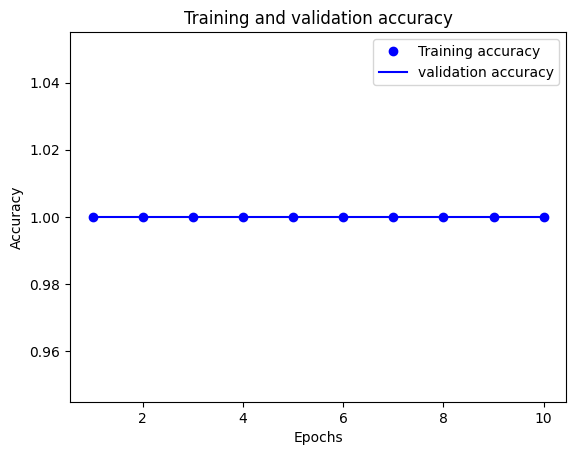

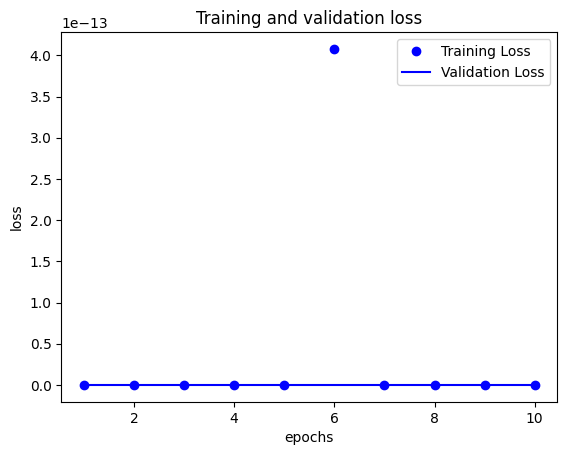

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9737 - loss: 0.7746
test accuracy :  0.9736841917037964


In [29]:

history = model.fit(
    train_features,
    train_labels,
    epochs=10,
    validation_data = (val_features, val_labels)
)

plot_acc_curves(history=history)
plot_loss_curves(history=history)
score = model.evaluate(test_features,test_labels)
print("test accuracy : ", score[1])